In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_nof_1wave_2d/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
Cadv = data_Cadv.Ah0.interp(time=data.time)
Cadv_int_ = data_Cadv.Ah0.integrate("time",datetime_unit="s")

In [6]:
from scipy import integrate

dt = (data.time.data-data.time[0].data).astype('int')*1e-9
Cadv_int = integrate.cumulative_trapezoid(Cadv.data, dt, axis=0, initial=0)

In [7]:
Cadv_int_.data - Cadv_int[-1,:,:]

array([[ 8.47409176e-33,  3.85185989e-33,  2.31111593e-33, ...,
         3.08148791e-33,  3.08148791e-33,  3.85185989e-33],
       [ 4.93038066e-32,  2.46519033e-32,  6.16297582e-32, ...,
         6.16297582e-32, -1.23259516e-32,  3.69778549e-32],
       [ 8.87468518e-31,  6.90253292e-31,  3.94430453e-31, ...,
         5.91645679e-31,  9.86076132e-32, -3.94430453e-31],
       ...,
       [ 4.44089210e-16, -2.22044605e-16,  0.00000000e+00, ...,
         0.00000000e+00, -2.22044605e-16, -3.33066907e-16],
       [-1.44328993e-15,  3.33066907e-16,  0.00000000e+00, ...,
        -8.88178420e-16, -3.33066907e-16, -3.33066907e-16],
       [ 2.22044605e-16, -1.11022302e-15,  9.99200722e-16, ...,
        -7.77156117e-16, -2.22044605e-16,  0.00000000e+00]],
      shape=(918, 125))

## Slope bathymetry & Shoaling depth

In [8]:
lambdaM2=70.1e3
l_sponge = 20e3
slope = 0.05
D0 = 600
He = 313.1
width_he2 = 26000
width_top = width_he2 - 2*(He/2)/slope
r = width_he2/2+(D0-He/2)/slope
width_base = 2*r

L=1.5*lambdaM2-width_top-(width_base-width_top)/2
W=l_sponge/2

x_c = L/2-(width_base-width_top)/4-width_top/2
y_c = W/2

In [9]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

In [10]:
x_top = L/2- D0/slope/2 #1.5*lambdaM2/2-width_top-(width_base-width_top)+width_top/2
x_bottom = x_top + D0/slope
x_shoal = x_top + depth_shoal/slope

## scale time

In [11]:
dt = (data.time.data-data.time[0].data).astype('int')*1e-9
c = 1.715370234806147
L_w = 6.387548003396961e+03/2

T_scale = L_w*2/c
t_nondim = dt/T_scale

# plot time-area integrated energy terms

In [12]:
idx_x = np.where((data.x.data>=x_top) & (data.x.data<=x_bottom))[0]

In [13]:
var = data_.C_int[:,idx_x,:].copy() + Cadv_int[:,idx_x,:]
var_ = var.integrate('x')
C_int = var_.integrate('y')

var = data.dissip_prime[:,idx_x,:].copy() - Cadv_int[:,idx_x,:]
var_ = var.integrate('x')
dissip_prime_int = var_.integrate('y')

var = data.dissip0[:,idx_x,:].copy() + Cadv_int[:,idx_x,:]
var_ = var.integrate('x')
dissip0_int = var_.integrate('y')

var = data_.dEp_prime[:,idx_x,:].copy()
var_ = var.integrate('x')
dEp_prime_int = var_.integrate('y')

var = data_.dEk_prime[:,idx_x,:].copy()
var_ = var.integrate('x')
dEk_prime_int = var_.integrate('y')

In [14]:
var = data_.D_prime[:,idx_x,:].copy()
var_ = var.integrate('x')
D_prime_int = var_.integrate('y')

var = data_.D0[:,idx_x,:].copy()
var_ = var.integrate('x')
D0_int = var_.integrate('y')

In [16]:
var = data_.dEp0[:,idx_x,:].copy()
var_ = var.integrate('x')
dEp0_int = var_.integrate('y')

var = data_.dEk0[:,idx_x,:].copy()
var_ = var.integrate('x')
dEk0_int = var_.integrate('y')

In [17]:
data_["ones"]=(['x', 'y'],  np.ones(data_.depth.shape))
var = data_.ones[idx_x,:].copy()
var_ = var.integrate('x')
area = var_.integrate('y')

In [18]:
area

<xarray.DataArray 'ones' ()> Size: 8B
array(1.18305821e+08)

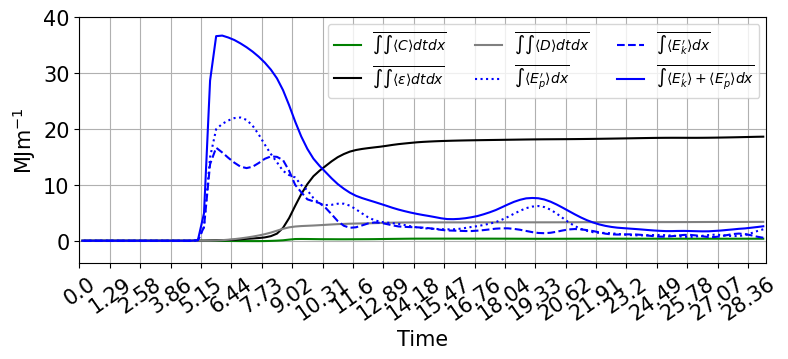

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/data.y[-1]*1e-6, c='g', label=r"$\overline{\int\int \langle C\rangle dtdx}$")
# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/data.y[-1]*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/data.y[-1]*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6+dissip0_int/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon\rangle dtdx}$")
ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6+D0_int/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D\rangle dtdx}$")

ax.plot(np.arange(len(data.time))[::-2], dEp_prime_int[::-2]/data.y[-1]*1e-6, c='b',ls=':', label=r"$\overline{\int\langle  E_p' \rangle dx}$")
ax.plot(np.arange(len(data.time))[::-2], dEk_prime_int[::-2]/data.y[-1]*1e-6, c='b',ls='--', label=r"$\overline{\int\langle  E_k' \rangle dx}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/data.y[-1]*1e-6, c='b', label=r"$\overline{\int \langle E_k'\rangle +\langle E_p'\rangle  dx}$")
ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'MJm$^{-1}$', fontsize=15)
ax.set_ylim([-4,40])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_yaverage_summer_nof_2d.png", transparent = True, dpi=300)

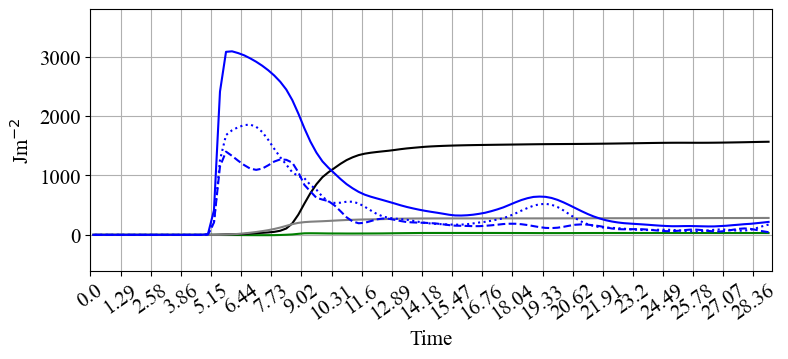

In [20]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/area, c='g', label=r"$\overline{\int\langle C\rangle dt}$")
# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/data.y[-1]*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/data.y[-1]*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/area+dissip0_int/area, c='k', label=r"$\overline{\int\langle \epsilon\rangle dt}$")
ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/area+D0_int/area, c='gray', label=r"$\overline{\int\langle  D\rangle dt}$")

ax.plot(np.arange(len(data.time))[::-2], dEp_prime_int[::-2]/area, c='b',ls=':', label=r"$\overline{\langle  E_p' \rangle}$")
ax.plot(np.arange(len(data.time))[::-2], dEk_prime_int[::-2]/area, c='b',ls='--', label=r"$\overline{\langle  E_k' \rangle}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/area, c='b', label=r"$\overline{\langle E_k'\rangle +\langle E_p'\rangle}$")
# ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'Jm$^{-2}$', fontsize=15)
ax.set_ylim([-600,3800])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_areaaverage_summer_nof_2d.png", transparent = True, dpi=300)

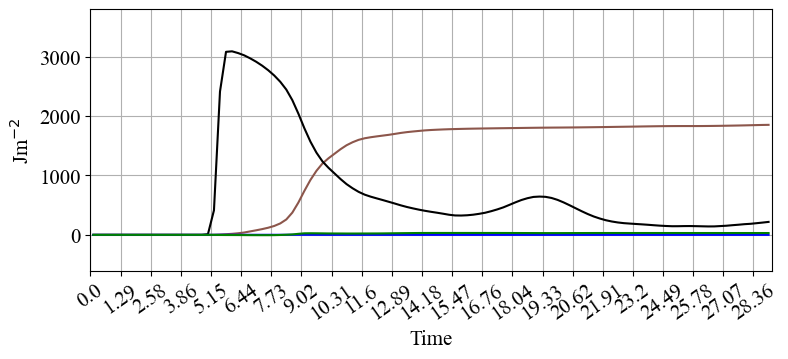

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3.7))

# ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/data.y[-1]*1e-6, c='k', label=r"$\overline{\int\int\langle \epsilon'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), dissip0_int/data.y[-1]*1e-6, c='k',ls='--', label=r"$\overline{\int\int\langle \epsilon_0\rangle dtdy}$")
# ax.plot(np.arange(len(data.time))[::-2], D_prime_int[::-2]/data.y[-1]*1e-6, c='gray', label=r"$\overline{\int\int\langle  D'\rangle dtdy}$")
# ax.plot(np.arange(len(data.time)), D0_int/data.y[-1]*1e-6, c='gray',ls='--', label=r"$\overline{\int\int\langle  D_0\rangle dtdy}$")
ax.plot(np.arange(len(data.time))[::-2], dissip_prime_int[::-2]/area+dissip0_int/area+D_prime_int[::-2]/area+D0_int/area, c='tab:brown', label=r"$\overline{\int\langle  \epsilon\rangle+D dt}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp_prime_int[::-2]+dEk_prime_int[::-2])/area, c='k', label=r"$\overline{\langle E_k'\rangle +\langle E_p'\rangle}$")
ax.plot(np.arange(len(data.time))[::-2], (dEp0_int[::-2]+dEk0_int[::-2])/area, c='b', label=r"$\overline{\langle E_{k0}\rangle +\langle E_{p0}\rangle}$")
ax.plot(np.arange(len(data.time))[::-2], C_int[::-2]/area, c='g', label=r"$\overline{\int\langle C\rangle dt}$")

# ax.legend(loc='upper right', ncol=3)
ax.set_ylabel(r'Jm$^{-2}$', fontsize=15)
ax.set_ylim([-600,3800])
ax.set_xlim([0,len(data.time)])
ax.set_xlabel('Time', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=15)
ax.tick_params(axis='x', rotation = 35)
ax.set_title('')
ax.set_xticks(np.arange(0,len(data.time)+1,10))
ax.set_xticklabels(np.round(t_nondim[np.arange(0,len(data.time)+1,10)],2))

plt.rcParams["font.family"] = "Times New Roman"  
plt.tight_layout()

ax.grid()

plt.savefig(outfilepath+ f"energy_int_areaaverage_summer_nof_2d.png", transparent = True, dpi=300)